# 2-0. 제주 수요 예측(장지평) — 관계 탐색·시계열 분석 (G-9)

> 모델링 공통 규율(G-9): 모델 착수 전 가벼운 EDA. 기존 제주 2단계(PatchTST+LGBM, **D+1만**)는
> 그대로 두고, land 5-A 틀을 이식한 **풀드 직접 다지평 LGBM(1~168h, D+1~D+7)** 을 새로 추가한다.
> 본 EDA 는 그 장지평 모델의 입력 가정(주간 lag·기상·달력)이 실제 데이터에 근거가 있는지만 확인한다.
>
> 타깃 `real_demand_jeju`(MW). 베이스라인 `jeju_est_demand_da`(KPX 하루전).
> 학습창 train ≤2025-02 / val ~2026-03 / test ~2026-05 (기존 제주 2단계와 동일).
>
> **점검**: ①결측·베이스라인오차 ②주기성(시간/요일/월) ③추세·안정성 ④기온↔수요 ⑤3지점
> 공간평균 타당성 ⑥예보 vs 실측(서빙 가능 기상) ⑦train↔test 겹침 ⑧자기상관(lag168 등).

In [1]:
import os, sqlite3, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
warnings.filterwarnings('ignore')
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['figure.dpi'] = 110

HERE = os.getcwd()
FIG = os.path.join(HERE, 'fig'); os.makedirs(FIG, exist_ok=True)
TAB = os.path.join(HERE, 'tab'); os.makedirs(TAB, exist_ok=True)
DB = os.path.normpath(os.path.join(HERE, '..', '..',
        '1. data_fetcher_and_db', 'data', 'input_data_jeju.db'))

STATIONS = ['west', 'east', 'south']
# 모델 기상 4종(제주 3지점 공간평균; 일사는 west/south 2지점 — east 풍력지점 일사 없음)
WX = ['temp_c', 'humidity', 'solar_rad', 'wind_spd']
SOLAR_ST = ['west', 'south']
pull = ['timestamp', 'real_demand_jeju', 'jeju_est_demand_da', 'day_type']
for st in STATIONS:
    for w in ['temp_c', 'humidity', 'wind_spd']:
        pull.append(f'{w}_{st}')
for st in SOLAR_ST:
    pull.append(f'solar_rad_{st}')

con = sqlite3.connect(DB)
df = pd.read_sql(f"SELECT {', '.join(pull)} FROM historical", con, parse_dates=['timestamp'])
con.close()
df = df.sort_values('timestamp').reset_index(drop=True)
# 제주 공간평균
df['temp_c']    = df[[f'temp_c_{st}'   for st in STATIONS]].mean(axis=1)
df['humidity']  = df[[f'humidity_{st}' for st in STATIONS]].mean(axis=1)
df['wind_spd']  = df[[f'wind_spd_{st}' for st in STATIONS]].mean(axis=1)
df['solar_rad'] = df[[f'solar_rad_{st}' for st in SOLAR_ST]].mean(axis=1)
df['year']  = df.timestamp.dt.year
df['month'] = df.timestamp.dt.month
df['hour']  = df.timestamp.dt.hour
df['dow']   = df.timestamp.dt.dayofweek
df['date']  = df.timestamp.dt.normalize()
print(df.shape, df.timestamp.min(), '~', df.timestamp.max())
df[['timestamp','real_demand_jeju','jeju_est_demand_da','temp_c','humidity','day_type']].head()

(56352, 24) 2020-01-01 00:00:00 ~ 2026-06-05 23:00:00


,timestamp,real_demand_jeju,jeju_est_demand_da,temp_c,humidity,day_type
0,2020-01-01 00:00:00,761.0,800.0,3.066667,70.333333,holiday
1,2020-01-01 01:00:00,723.0,710.0,2.900000,72.000000,holiday
2,2020-01-01 02:00:00,688.0,690.0,3.133333,73.000000,holiday
3,2020-01-01 03:00:00,659.0,670.0,3.266667,73.000000,holiday
4,2020-01-01 04:00:00,653.0,660.0,3.433333,72.000000,holiday


## 1. 데이터 품질 — 결측·이상치·베이스라인 오차

타깃 결측(시간보간 대상)·0값 점검, 그리고 우리가 이겨야 할 KPX 하루전 베이스라인 MAPE.

In [2]:
y = df['real_demand_jeju']
print('real_demand_jeju  : NaN=%d  zero=%d  min=%.0f  max=%.0f  mean=%.0f'
      % (y.isna().sum(), (y==0).sum(), y.min(), y.max(), y.mean()))
print('jeju_est_demand_da: NaN=%d' % df.jeju_est_demand_da.isna().sum())

# 타깃 0/결측 → 시간보간 (dropna 금지 규칙)
d = df.copy()
d.loc[d.real_demand_jeju==0,'real_demand_jeju'] = np.nan
d['real_demand_jeju'] = d.set_index('timestamp')['real_demand_jeju'].interpolate(method='time').values
for w in WX:
    d[w] = d.set_index('timestamp')[w].interpolate(method='time').values

def mape(a,b):
    a=np.asarray(a,float); b=np.asarray(b,float)
    m=(a>0)&(~np.isnan(a))&(~np.isnan(b)); return float(np.mean(np.abs(a[m]-b[m])/a[m])*100)
rows=[]
for yr,g in d.groupby('year'):
    rows.append(dict(year=yr, n=len(g), dem_nan=int(df[df.year==yr].real_demand_jeju.isna().sum()),
                     dem_mean=round(g.real_demand_jeju.mean(),1),
                     base_mape=round(mape(g.real_demand_jeju.values, g.jeju_est_demand_da.values),3)))
summary = pd.DataFrame(rows)
summary.to_csv(os.path.join(TAB,'2-0_year_summary.csv'), index=False)
print(summary.to_string(index=False))

real_demand_jeju  : NaN=10  zero=5  min=0  max=1916  mean=703
jeju_est_demand_da: NaN=0
 year    n  dem_nan  dem_mean  base_mape
 2020 8784        0     643.8      6.387
 2021 8760        0     670.2      6.980
 2022 8760        0     710.5      7.008
 2023 8760        0     721.8      5.963
 2024 8784        0     739.7      5.891
 2025 8760        0     732.6      5.802
 2026 3744       10     702.7      6.158


## 2. 시계열 구조 — 주기성 (시간 / 요일 / 월)

제주 수요의 일중(생활·업무)·주간(평일/주말)·계절 패턴. 달력 피처(hour/dow/month sin·cos) 근거.

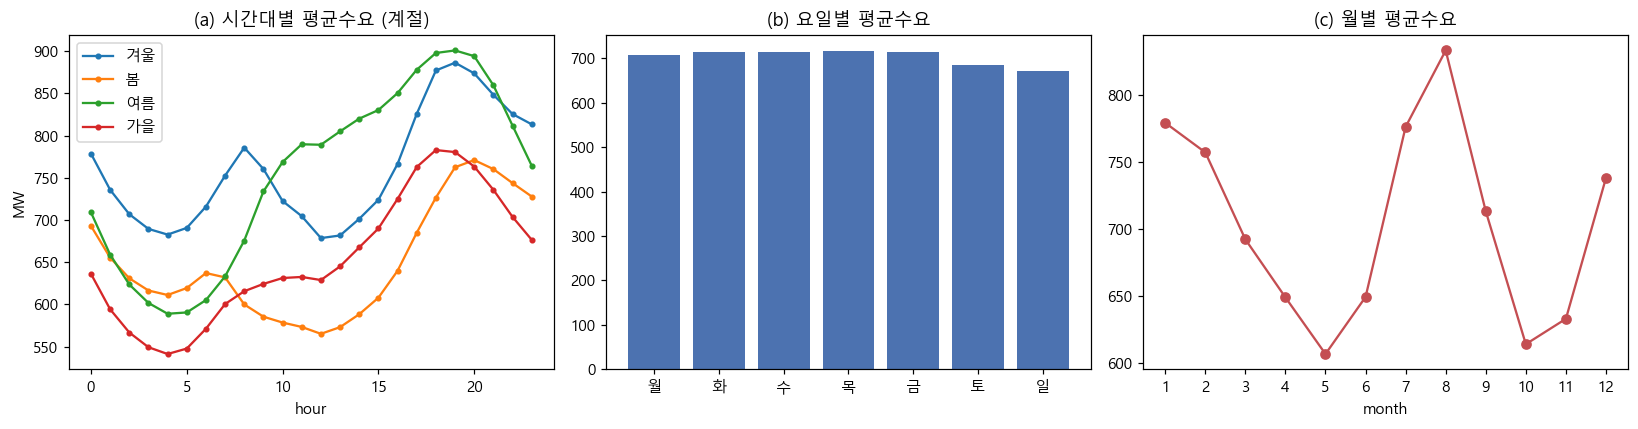

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15,4))
d['season'] = d.month.map({12:'겨울',1:'겨울',2:'겨울',3:'봄',4:'봄',5:'봄',
                           6:'여름',7:'여름',8:'여름',9:'가을',10:'가을',11:'가을'})
for s in ['겨울','봄','여름','가을']:
    p = d[d.season==s].groupby('hour').real_demand_jeju.mean()
    ax[0].plot(p.index, p.values, marker='o', ms=3, label=s)
ax[0].set_title('(a) 시간대별 평균수요 (계절)'); ax[0].set_xlabel('hour'); ax[0].set_ylabel('MW'); ax[0].legend()
dd = ['월','화','수','목','금','토','일']
p = d.groupby('dow').real_demand_jeju.mean()
ax[1].bar([dd[i] for i in p.index], p.values, color='#4C72B0'); ax[1].set_title('(b) 요일별 평균수요')
p = d.groupby('month').real_demand_jeju.mean()
ax[2].plot(p.index, p.values, marker='o', color='#C44E52'); ax[2].set_title('(c) 월별 평균수요')
ax[2].set_xlabel('month'); ax[2].set_xticks(range(1,13))
plt.tight_layout(); plt.savefig(os.path.join(FIG,'2-0_seasonality.png'), bbox_inches='tight'); plt.show()

## 3. 추세 & 시간적 안정성 (연도별 레짐)

제주 수요 레벨 표류 점검 — 표류가 크면 lag/level 피처·학습창 설계에 영향.

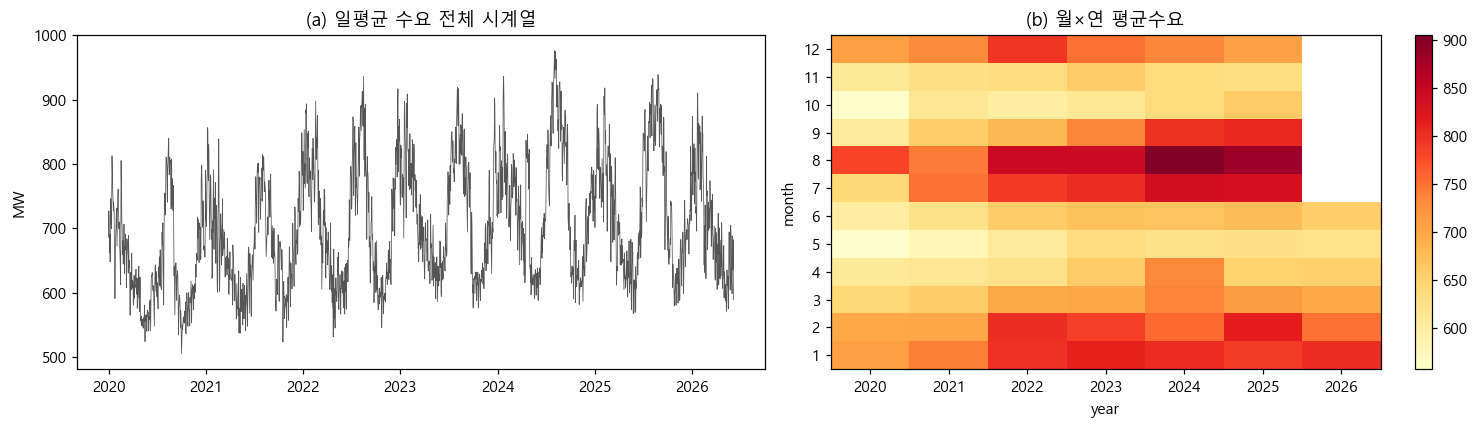

연평균 수요(MW):
year
2020    644.0
2021    670.0
2022    710.0
2023    722.0
2024    740.0
2025    733.0
2026    703.0

연도별 표준편차(MW):
year
2020    108.0
2021    116.0
2022    139.0
2023    128.0
2024    136.0
2025    137.0
2026    119.0


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))
daily = d.groupby('date').real_demand_jeju.mean()
ax[0].plot(daily.index, daily.values, lw=0.5, color='#555')
ax[0].set_title('(a) 일평균 수요 전체 시계열'); ax[0].set_ylabel('MW')
piv = d.pivot_table('real_demand_jeju','month','year','mean')
im = ax[1].imshow(piv.values, aspect='auto', cmap='YlOrRd', origin='lower')
ax[1].set_xticks(range(len(piv.columns))); ax[1].set_xticklabels(piv.columns)
ax[1].set_yticks(range(12)); ax[1].set_yticklabels(range(1,13))
ax[1].set_title('(b) 월×연 평균수요'); ax[1].set_xlabel('year'); ax[1].set_ylabel('month')
plt.colorbar(im, ax=ax[1])
plt.tight_layout(); plt.savefig(os.path.join(FIG,'2-0_trend.png'), bbox_inches='tight'); plt.show()
print('연평균 수요(MW):'); print(d.groupby('year').real_demand_jeju.mean().round(0).to_string())
print('\n연도별 표준편차(MW):'); print(d.groupby('year').real_demand_jeju.std().round(0).to_string())

## 4. 기온 ↔ 수요 관계 (냉난방 U/V자)

제주 수요의 최대 외생 동인. 저온(난방)·고온(냉방)에서 수요 상승 기대. 선형상관은 작아도
트리 모델이 잡는 비선형 구조를 구간평균으로 확인.

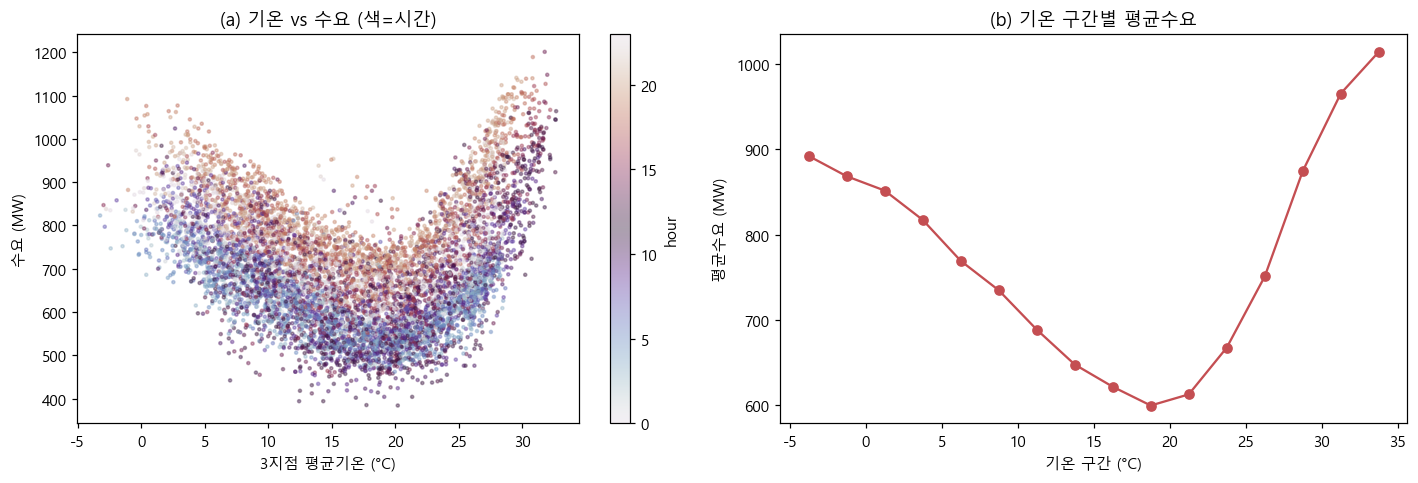

상관(피어슨):
  temp_c     -0.004
  humidity   +0.065
  solar_rad  -0.100
  wind_spd   +0.101


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
samp = d.sample(min(8000,len(d)), random_state=0)
sc = ax[0].scatter(samp.temp_c, samp.real_demand_jeju, s=4, c=samp.hour, cmap='twilight', alpha=.4)
ax[0].set_xlabel('3지점 평균기온 (°C)'); ax[0].set_ylabel('수요 (MW)')
ax[0].set_title('(a) 기온 vs 수요 (색=시간)'); plt.colorbar(sc, ax=ax[0], label='hour')
d['tbin'] = pd.cut(d.temp_c, bins=np.arange(-5,38,2.5))
p = d.groupby('tbin').real_demand_jeju.mean()
cx = [iv.mid for iv in p.index]
ax[1].plot(cx, p.values, marker='o', color='#C44E52')
ax[1].set_xlabel('기온 구간 (°C)'); ax[1].set_ylabel('평균수요 (MW)'); ax[1].set_title('(b) 기온 구간별 평균수요')
plt.tight_layout(); plt.savefig(os.path.join(FIG,'2-0_temp_demand.png'), bbox_inches='tight'); plt.show()
print('상관(피어슨):')
for c in WX:
    print('  %-10s %+.3f' % (c, d[['real_demand_jeju',c]].corr().iloc[0,1]))

## 5. 3지점 기상 비교 & 공간평균 타당성

기존 제주 2단계는 3지점 공간평균이 단일지점보다 좋았다. 지점 간 상관·대표성으로 재확인.

In [6]:
tcols = [f'temp_c_{st}' for st in STATIONS]
corr = df[tcols].corr(); corr.columns = STATIONS; corr.index = STATIONS
print('3지점 기온 상관행렬:'); print(corr.round(3).to_string())
print('\n지점별 기온↔수요 상관:')
for st in STATIONS:
    c = pd.concat([d.real_demand_jeju, df[f'temp_c_{st}']],axis=1).corr().iloc[0,1]
    print('  %-6s %+.3f' % (st, c))
print('\n3지점 평균 기온↔수요 상관: %+.3f' % d[['real_demand_jeju','temp_c']].corr().iloc[0,1])

3지점 기온 상관행렬:
        west   east  south
west   1.000  0.977  0.974
east   0.977  1.000  0.983
south  0.974  0.983  1.000

지점별 기온↔수요 상관:
  west   +0.012
  east   -0.015
  south  -0.008

3지점 평균 기온↔수요 상관: -0.004


## 6. 예보 vs 실측 기상 정합 — 서빙 가능 피처 (★)

장지평 서빙(D+1~D+7)도 forecast 테이블에 있는 기상만 입력 가능. 제주 forecast 매핑 확인.
land 와 달리 제주는 **습도(reh)가 있어** 4종 모두 서빙 가능.

In [7]:
con = sqlite3.connect(DB)
fc = pd.read_sql('SELECT * FROM forecast', con, parse_dates=['timestamp'])
con.close()
mapping = {'temp_c':'temp', 'humidity':'reh', 'solar_rad':'radiation', 'wind_spd':'wind_spd_10m'}
rows=[]
for hcol, fcol in mapping.items():
    avail = any(c.startswith(fcol+'_') for c in fc.columns)
    rows.append(dict(historical=hcol, forecast=fcol, 서빙가능=('O' if avail else 'X')))
mp = pd.DataFrame(rows); mp.to_csv(os.path.join(TAB,'2-0_feature_availability.csv'), index=False)
print(mp.to_string(index=False))
print('\nforecast 범위:', fc.timestamp.min(),'~',fc.timestamp.max(),' rows=',len(fc))
print('forecast day_type 존재:', 'day_type' in fc.columns,
      '| jeju_est_demand_da 존재:', 'jeju_est_demand_da' in fc.columns)

historical     forecast 서빙가능
    temp_c         temp    O
  humidity          reh    O
 solar_rad    radiation    O
  wind_spd wind_spd_10m    O

forecast 범위: 2025-12-13 00:00:00 ~ 2026-06-07 23:00:00  rows= 4248
forecast day_type 존재: True | jeju_est_demand_da 존재: True


## 7. train↔test 분포 겹침 (covariate shift)

train(≤2025-02)·test(2026) 입력 분포가 겹쳐야 정직한 검증. 기온·수요 분포로 확인.

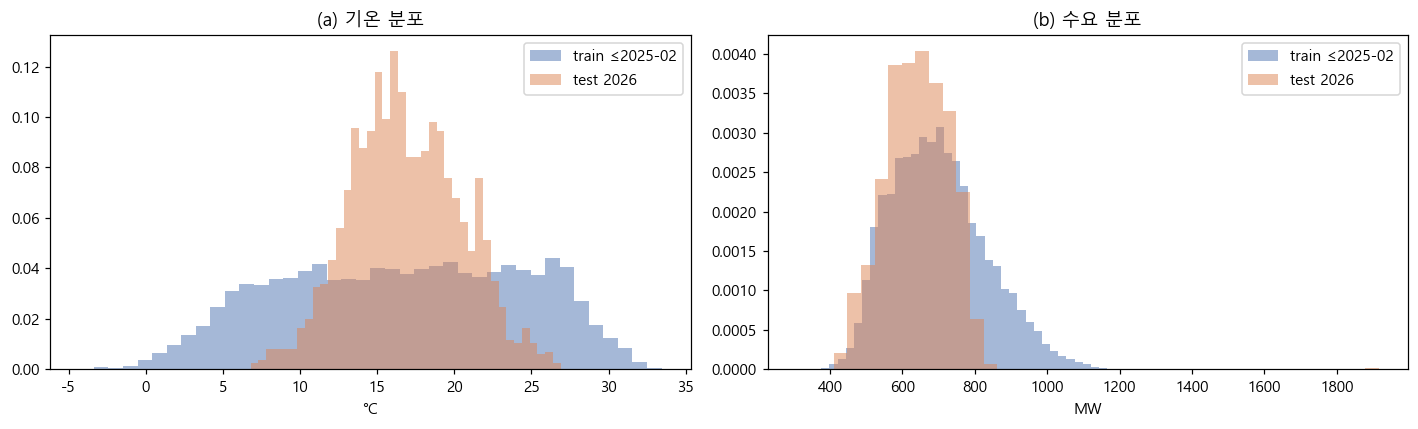

test 2026 가 train 범위(0.1~99.9%) 밖 비율:
  temp_c             0.00%
  real_demand_jeju   0.06%

test 기간: 2026-03-22 00:00:00 ~ 2026-05-31 23:00:00


In [8]:
ts = d['timestamp']
tr = d[ts <= '2025-02-28 23:00']; te = d[(ts >= '2026-03-22') & (ts <= '2026-05-31 23:00')]
fig, ax = plt.subplots(1,2, figsize=(13,4))
for name,g,c in [('train ≤2025-02',tr,'#4C72B0'),('test 2026',te,'#DD8452')]:
    ax[0].hist(g.temp_c.dropna(), bins=40, density=True, alpha=.5, label=name, color=c)
    ax[1].hist(g.real_demand_jeju.dropna(), bins=40, density=True, alpha=.5, label=name, color=c)
ax[0].set_title('(a) 기온 분포'); ax[0].set_xlabel('°C'); ax[0].legend()
ax[1].set_title('(b) 수요 분포'); ax[1].set_xlabel('MW'); ax[1].legend()
plt.tight_layout(); plt.savefig(os.path.join(FIG,'2-0_covariate_shift.png'), bbox_inches='tight'); plt.show()
def outside(col):
    lo,hi = tr[col].quantile([.001,.999]); return float(((te[col]<lo)|(te[col]>hi)).mean()*100)
print('test 2026 가 train 범위(0.1~99.9%) 밖 비율:')
for c in ['temp_c','real_demand_jeju']:
    print('  %-18s %.2f%%' % (c, outside(c)))
print('\ntest 기간:', te.timestamp.min(),'~',te.timestamp.max())

## 8. 자기상관 — lag 구조 (장지평 lag168 근거)

장지평 모델의 척추는 **lag168(주간)**. 전 지평(h≤168) 직접 가용하므로 누수 없이 쓸 수 있다.
일주기(lag24)·주주기(lag168) 자기상관과 rec24/rec168 레벨 신호를 확인.

In [9]:
s = d.set_index('timestamp').real_demand_jeju
lags = [1,2,3,6,12,24,48,168,336]
print('자기상관(전구간):')
for L in lags:
    print('  lag %4dh : %+.3f' % (L, s.autocorr(L)))
rec24  = s.shift(1).rolling(24,min_periods=24).mean()
rec168 = s.shift(1).rolling(168,min_periods=168).mean()
print('\nrec24(직전24h평균) ↔ 현재수요 상관 : %+.3f' % pd.concat([s,rec24],axis=1).corr().iloc[0,1])
print('rec168(직전168h평균) ↔ 현재수요 상관: %+.3f' % pd.concat([s,rec168],axis=1).corr().iloc[0,1])
print('lag168 ↔ 현재수요 상관            : %+.3f' % pd.concat([s,s.shift(168)],axis=1).corr().iloc[0,1])

자기상관(전구간):
  lag    1h : +0.956
  lag    2h : +0.876
  lag    3h : +0.772
  lag    6h : +0.438
  lag   12h : +0.201
  lag   24h : +0.894
  lag   48h : +0.843
  lag  168h : +0.822
  lag  336h : +0.771

rec24(직전24h평균) ↔ 현재수요 상관 : +0.692
rec168(직전168h평균) ↔ 현재수요 상관: +0.648
lag168 ↔ 현재수요 상관            : +0.822


## 9. 요약 & 결론 (모델 결정 확정용)

사용자 확정 피처셋(15개)이 데이터에 근거가 있는지 정리한다.

In [10]:
report = f'''# 2-0 EDA 요약 — 제주 수요 예측(장지평) (G-9)

## 데이터
- 타깃 real_demand_jeju: {df.timestamp.min():%Y-%m} ~ {df.timestamp.max():%Y-%m-%d}, {len(df):,}행.
  NaN={int(df.real_demand_jeju.isna().sum())}(시간보간), 0값={int((df.real_demand_jeju==0).sum())}.
- 베이스라인 jeju_est_demand_da(KPX 하루전): 연도별 base MAPE 표 참조(tab/2-0_year_summary.csv).
- 학습창: train ≤2025-02 / val ~2026-03 / test ~2026-05 (기존 제주 2단계와 동일).

## 시계열 구조
- 일/주/계절 주기 뚜렷(그림 2-0_seasonality). 자기상관 lag24={s.autocorr(24):+.3f}, lag168={s.autocorr(168):+.3f}.
- 기온↔수요 비선형(U/V자, 그림 2-0_temp_demand). 3지점 평균기온↔수요 상관 {d[['real_demand_jeju','temp_c']].corr().iloc[0,1]:+.3f}.
- rec24↔수요 {pd.concat([s,s.shift(1).rolling(24,min_periods=24).mean()],axis=1).corr().iloc[0,1]:+.3f}, rec168↔수요 {pd.concat([s,s.shift(1).rolling(168,min_periods=168).mean()],axis=1).corr().iloc[0,1]:+.3f} → 레벨 신호 유효.

## 서빙 제약 (예보에 있는 변수만)
- 서빙 가능(O): temp_c, humidity, solar_rad, wind_spd (제주 3지점 평균/일사 2지점).
  → land 와 달리 **습도 서빙 가능** → 사용자 확정대로 기상 4종 유지.

## train↔test 분포
- 2026 test 가 train 분포 안에 겹침(표 참조) → 정직한 검증 가능.

## 확정 피처(15개, 사용자 확정 — Decision Gate)
- h, lag168, rec24, rec168, 기상4(temp_c/humidity/solar_rad/wind_spd),
  hour_sin/cos, dow_sin/cos, month_sin/cos, day_type.
- 구조: LGBM 단독·풀드 직접 다지평 1~168h(D+1~D+7), origin 23:00. (lag24·과거 land의 h 외 제거 결정 반영: lag24 제외, h 유지)
- 기존 PatchTST+LGBM D+1 파이프라인은 그대로 유지. D+1(24h)에서 정확도 비교 예정.

→ 결론: 주간 lag·기상·달력 가정 모두 데이터에 근거 있음. **G-9 통과**, 2-A 학습 진행.
'''
with open(os.path.join(HERE,'REPORT_2-0_eda.md'),'w',encoding='utf-8') as f:
    f.write(report)
print(report)

# 2-0 EDA 요약 — 제주 수요 예측(장지평) (G-9)

## 데이터
- 타깃 real_demand_jeju: 2020-01 ~ 2026-06-05, 56,352행.
  NaN=10(시간보간), 0값=5.
- 베이스라인 jeju_est_demand_da(KPX 하루전): 연도별 base MAPE 표 참조(tab/2-0_year_summary.csv).
- 학습창: train ≤2025-02 / val ~2026-03 / test ~2026-05 (기존 제주 2단계와 동일).

## 시계열 구조
- 일/주/계절 주기 뚜렷(그림 2-0_seasonality). 자기상관 lag24=+0.894, lag168=+0.822.
- 기온↔수요 비선형(U/V자, 그림 2-0_temp_demand). 3지점 평균기온↔수요 상관 -0.004.
- rec24↔수요 +0.692, rec168↔수요 +0.648 → 레벨 신호 유효.

## 서빙 제약 (예보에 있는 변수만)
- 서빙 가능(O): temp_c, humidity, solar_rad, wind_spd (제주 3지점 평균/일사 2지점).
  → land 와 달리 **습도 서빙 가능** → 사용자 확정대로 기상 4종 유지.

## train↔test 분포
- 2026 test 가 train 분포 안에 겹침(표 참조) → 정직한 검증 가능.

## 확정 피처(15개, 사용자 확정 — Decision Gate)
- h, lag168, rec24, rec168, 기상4(temp_c/humidity/solar_rad/wind_spd),
  hour_sin/cos, dow_sin/cos, month_sin/cos, day_type.
- 구조: LGBM 단독·풀드 직접 다지평 1~168h(D+1~D+7), origin 23:00. (lag24·과거 land의 h 외 제거 결정 반영: lag24 제외, h 유지)
- 기존 PatchTST+LGBM D+1 파이프라인은 그대로 유지. D+1(24h)에서 정확도 비교 예정.

→ 결론: 